In [1]:
!pip install numpy opencv-python matplotlib

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [9]:
import os
asl_sentence_vid = '/content/drive/MyDrive/ASL_Video_Clips/ASL TEACHER YOU_.mp4'
output_dir = '/content/drive/MyDrive/ASL_Video_Clips/ASL TEACHER YOU'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [4]:
!pip install mediapipe

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.9/35.9 MB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.6/294.6 kB 16.1 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 3.20.3
    Uninstalling protobuf-3.20.3:
      Successfully uninstalled protobuf-3.20.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-metadata 1.15.0 requires protobuf<4.21,>=3.20.3; python_version < "3.11", but you have protobuf 4.25.5 which is incompatible.


In [5]:
!pip install ruptures

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 12.5 MB/s eta 0:00:00


# **1st approach**

1. Hand Detection Confidence Threshold (MediaPipe)
Current Parameter: min_detection_confidence=0.5
Description: This is the confidence level of the hand detection in MediaPipe. Increasing this confidence threshold will ensure that only stronger (more confident) hand detections are considered. If the detection confidence is low, it might be picking up more frames than necessary.
Tuning: Increase the min_detection_confidence to a higher value, such as 0.7 or 0.8, to reduce the sensitivity of hand detections.
2. Smoothing Motion with a Moving Average -
Description: To prevent small fluctuations in hand motion from triggering a pause, you can calculate a moving average of the motion across several frames. This will smooth out rapid changes in motion and make it less sensitive to small adjustments.

In [46]:
import cv2
import numpy as np
import mediapipe as mp
import os
from google.colab.patches import cv2_imshow #cv2.imshow() is disabled in Colab, because it causes Jupyter sessions to crash; As a substitution, consider using from google.colab.patches import cv2_imshow

# Initialize MediaPipe Hands
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(static_image_mode=False, max_num_hands=2, min_detection_confidence=0.5)

# Load the video
cap = cv2.VideoCapture(asl_sentence_vid)

# Check if the video opened successfully
if not cap.isOpened():
    print("Error opening video file")
    exit()

# Get video properties
fps = cap.get(cv2.CAP_PROP_FPS)  # Frames per second
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))  # Total number of frames
duration = total_frames / fps  # Total video duration in seconds

# Define frame ranges to process (reject the first and last 10% of frames)
start_frame = int(0.1 * total_frames)
end_frame = int(0.9 * total_frames)

##### Parameters for motion smoothing and detection ******************************************
motion_threshold = 0.01  # Tune this value to detect motion pauses
min_pause_frames = int(fps /2)  # Ensures roughly 2 words per second
motion_window_size = 1  # Number of frames to average over

# Initialize variables for word counting
word_frames = []  # Store frames associated with each word
word_count = 0
frame_count = 0
motion_history = []  # List to store recent motion values
last_pause_frame = start_frame
prev_landmarks = None

# Set the starting frame
cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret or frame_count >= end_frame:
        break

    frame_count += 1
    current_frame_position = int(cap.get(cv2.CAP_PROP_POS_FRAMES))

    # Convert the frame to RGB for MediaPipe
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Detect hands using MediaPipe
    results = hands.process(frame_rgb)

    if results.multi_hand_landmarks:
        for hand_landmarks in results.multi_hand_landmarks:
            landmarks = np.array([[lm.x, lm.y] for lm in hand_landmarks.landmark])

            # If there are previous landmarks, calculate the motion
            if prev_landmarks is not None:
                motion = np.linalg.norm(landmarks - prev_landmarks, axis=1).mean()

                # Add the motion value to the history and smooth it
                motion_history.append(motion)
                if len(motion_history) > motion_window_size:
                    motion_history.pop(0)  # Keep the window size constant

                avg_motion = np.mean(motion_history)  # Calculate the moving average

                # Detect a pause if motion is below the threshold and enough time has passed since the last word
                if avg_motion < motion_threshold and (current_frame_position - last_pause_frame > min_pause_frames):
                    word_count += 1
                    frame_filename = f'{output_dir}/word_{word_count}_frame_{current_frame_position}.jpg'
                    cv2.imwrite(frame_filename, frame)
                    print(f"Saved frame {current_frame_position} as {frame_filename}")

                    # Update the last detected pause frame
                    last_pause_frame = current_frame_position

            # Update previous landmarks
            prev_landmarks = landmarks

    # Display the frame (optional, for visualization)
    #cv2.imshow('ASL Video with Hand Detection', frame)
    #replace with cv2.imshow when runing out of google colab
    #cv2_imshow(frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release the video capture and close windows
cap.release()
cv2.destroyAllWindows()


/usr/local/lib/python3.10/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


Saved frame 31 as /content/drive/MyDrive/ASL_Video_Clips/BOOK YOU LIKE READ, WHAT-KIND-word/word_1_frame_31.jpg


KeyboardInterrupt: 

In [ ]:
fps

In [ ]:
total_frames

In [ ]:
word_count

In [ ]:
frame_count

# **# 2nd approach:**
Add a "Fast Motion" Segment Detection:
Since the middle word has high movement, you can add logic that ensures high-motion segments are treated as potential word segments, even if there is no pause. This can capture fast-signing words.

In [ ]:
import cv2
import numpy as np
import mediapipe as mp
import os
from google.colab.patches import cv2_imshow

# Initialize MediaPipe Hands
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(static_image_mode=False, max_num_hands=2, min_detection_confidence=0.7)

# Load the video
cap = cv2.VideoCapture(asl_sentence_vid)

# Get video properties
fps = cap.get(cv2.CAP_PROP_FPS)  # Frames per second
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))  # Total number of frames
duration = total_frames / fps  # Total video duration in seconds

# Define frame ranges to process (reject the first and last 10% of frames)
start_frame = int(0.1 * total_frames)
end_frame = int(0.9 * total_frames)

# Directory to save word frames
output_dir = 'word_frames'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Parameters for motion smoothing and detection
motion_threshold = 0.01  # Reduce threshold to capture subtle pauses
high_motion_threshold = 0.15  # Detect high motion for fast movements
min_pause_frames = int(fps / 1.25)  # Ensures roughly 1.25 words per second
motion_history = []  # List to store recent motion values
motion_window_size = 5  # Number of frames to average over
word_count = 0
frame_count = 0
last_pause_frame = start_frame
prev_landmarks = None
high_motion_detected = False

# Set the starting frame
cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret or frame_count >= end_frame:
        break

    frame_count += 1
    current_frame_position = int(cap.get(cv2.CAP_PROP_POS_FRAMES))

    # Convert the frame to RGB for MediaPipe
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Detect hands using MediaPipe
    results = hands.process(frame_rgb)

    if results.multi_hand_landmarks:
        for hand_landmarks in results.multi_hand_landmarks:
            landmarks = np.array([[lm.x, lm.y] for lm in hand_landmarks.landmark])

            # If there are previous landmarks, calculate the motion
            if prev_landmarks is not None:
                motion = np.linalg.norm(landmarks - prev_landmarks, axis=1).mean()

                # Add the motion value to the history and smooth it
                motion_history.append(motion)
                if len(motion_history) > motion_window_size:
                    motion_history.pop(0)  # Keep the window size constant

                avg_motion = np.mean(motion_history)  # Calculate the moving average

                # Detect fast hand movements as a potential word segment
                if avg_motion > high_motion_threshold:
                    high_motion_detected = True

                # Detect a pause if motion is below the threshold and enough time has passed since the last word
                if avg_motion < motion_threshold and (current_frame_position - last_pause_frame > min_pause_frames):
                    if high_motion_detected or current_frame_position - last_pause_frame > min_pause_frames:
                        word_count += 1
                        frame_filename = f'{output_dir}/word_{word_count}_frame_{current_frame_position}.jpg'
                        cv2.imwrite(frame_filename, frame)
                        print(f"Saved frame {current_frame_position} as {frame_filename}")

                        # Reset high motion detection
                        high_motion_detected = False

                        # Update the last detected pause frame
                        last_pause_frame = current_frame_position

            # Update previous landmarks
            prev_landmarks = landmarks

    # Display the frame (optional, for visualization)
    #cv2.imshow('ASL Video with Hand Detection', frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release the video capture and close windows
cap.release()
cv2.destroyAllWindows()


Saved frame 33 as word_frames/word_1_frame_33.jpg
Saved frame 65 as word_frames/word_2_frame_65.jpg


# **3rd approach**

Let's use a different approach.
We know there are at the most 1.25 words per second, and we also know first and last 10% of the video is filler hence can be ignored.
So, we can estimate the number of words in the video. Let's say that is n.
Now, if try to find n groups of frames, where the frames are very similar among the group but each group is different from another group.
Write me a python program with this algorithm.

In [50]:
!pip install ruptures

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.9 MB/s eta 0:00:00


In [51]:
import cv2
import numpy as np
import ruptures as rpt
import os

# Function to extract features from a frame (resize and flatten)
def extract_frame_features(frame, size=(64, 64)):
    resized_frame = cv2.resize(frame, size)  # Resize the frame for feature extraction
    return resized_frame.flatten()  # Flatten the frame into a 1D array

# Load video and extract properties
cap = cv2.VideoCapture(asl_sentence_vid)
fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
duration = total_frames / fps

# Ignore first and last 10% of frames
start_frame = int(0.1 * total_frames)
end_frame = int(0.9 * total_frames)

# Estimate the number of words based on 1.25 words per second
words_per_second = 1.25
estimated_words = int((end_frame - start_frame) / fps * words_per_second)

# Extract the frames to be processed and their features
frames = []
frame_indices = []
raw_frames = []  # To store raw frames for saving later

cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)  # Set to the start frame

while cap.isOpened():
    ret, frame = cap.read()
    current_frame_position = int(cap.get(cv2.CAP_PROP_POS_FRAMES))

    if not ret or current_frame_position >= end_frame:
        break

    # Store the actual frame in memory for later retrieval
    raw_frames.append(frame)

    # Extract features from the frame
    frame_features = extract_frame_features(frame)
    frames.append(frame_features)
    frame_indices.append(current_frame_position)

cap.release()

# Convert frames list to a numpy array
frames_np = np.array(frames)

# Change point detection using Kernel method
model = rpt.KernelCPD(kernel="linear").fit(frames_np)
change_points = model.predict(n_bkps=estimated_words)

# Save a representative frame from each segment
for i in range(len(change_points) - 1):
    segment_start = change_points[i]
    segment_end = change_points[i + 1]

    # Select a middle frame from the segment as the representative frame
    mid_frame_index = (segment_start + segment_end) // 2

    # Fetch the raw frame from memory (raw_frames) and save it
    representative_frame = raw_frames[mid_frame_index]
    frame_index = frame_indices[mid_frame_index]

    if representative_frame is not None:
        frame_filename = f'{output_dir}/word_{i + 1}_frame_{frame_index}.jpg'
        cv2.imwrite(frame_filename, representative_frame)
        print(f"Saved frame {frame_index} as {frame_filename}")

print(f"Estimated words: {estimated_words}")


Saved frame 67 as /content/drive/MyDrive/ASL_Video_Clips/BOOK YOU LIKE READ, WHAT-KIND-word/word_1_frame_67.jpg
Saved frame 91 as /content/drive/MyDrive/ASL_Video_Clips/BOOK YOU LIKE READ, WHAT-KIND-word/word_2_frame_91.jpg
Saved frame 107 as /content/drive/MyDrive/ASL_Video_Clips/BOOK YOU LIKE READ, WHAT-KIND-word/word_3_frame_107.jpg
Saved frame 124 as /content/drive/MyDrive/ASL_Video_Clips/BOOK YOU LIKE READ, WHAT-KIND-word/word_4_frame_124.jpg
Saved frame 140 as /content/drive/MyDrive/ASL_Video_Clips/BOOK YOU LIKE READ, WHAT-KIND-word/word_5_frame_140.jpg
Estimated words: 5


In [ ]:
total_frames

93

In [ ]:
change_points

[28, 43, 52, 73]

# **4th Approach**
To provide more weight to the starting of the video, as the last method missed the 1st word.

In [ ]:
import cv2
import numpy as np
import ruptures as rpt
import os

# Function to extract features from a frame (resize and flatten)
def extract_frame_features(frame, size=(64, 64)):
    resized_frame = cv2.resize(frame, size)  # Resize the frame for feature extraction
    return resized_frame.flatten()  # Flatten the frame into a 1D array

# Load video and extract properties
cap = cv2.VideoCapture(asl_sentence_vid)
fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
duration = total_frames / fps

# Reduce the skipped portion to 5% to include more of the first word
start_frame = int(0.05 * total_frames)
end_frame = int(0.9 * total_frames)

# Total number of frames left after removing the first and last portions
f = end_frame - start_frame

# Estimate the number of words based on 1.25 words per second
words_per_second = 1.25
estimated_words = int((end_frame - start_frame) / fps * words_per_second)

# Calculate buffer size as 90% of frames per word
frames_per_word = f / estimated_words
buffer_size = int(0.9 * frames_per_word)

# Extract the frames to be processed and their features
frames = []
frame_indices = []
raw_frames = []  # To store raw frames for saving later

cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)  # Set to the start frame

while cap.isOpened():
    ret, frame = cap.read()
    current_frame_position = int(cap.get(cv2.CAP_PROP_POS_FRAMES))

    if not ret or current_frame_position >= end_frame:
        break

    # Store the actual frame in memory for later retrieval
    raw_frames.append(frame)

    # Extract features from the frame
    frame_features = extract_frame_features(frame)
    frames.append(frame_features)
    frame_indices.append(current_frame_position)

cap.release()

# Convert frames list to a numpy array
frames_np = np.array(frames)

# Change point detection using Kernel method
model = rpt.KernelCPD(kernel="linear").fit(frames_np)

# Force the first change point to be early in the video (first 5% of frames)
first_change_point = int(0.05 * len(frames_np))

# Use dynamic programming to find change points, forcing the first one to be early
change_points = model.predict(n_bkps=estimated_words)

# Manually insert the first change point if not detected early
if change_points[0] > first_change_point:
    change_points = [first_change_point] + change_points

# Directory to save word frames and mini videos
output_dir = output_dir + '/segmented_word_videos'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Save mini video clips for each word
for i in range(len(change_points) - 1):
    segment_start = change_points[i]
    segment_end = change_points[i + 1]

    # Select the middle frame of the segment
    mid_frame_index = (segment_start + segment_end) // 2

    # Get the range of frames to create the mini video based on the calculated buffer size
    start_range = max(0, mid_frame_index - buffer_size // 2)
    end_range = min(len(raw_frames) - 1, mid_frame_index + buffer_size // 2)

    # Create a VideoWriter object to save the mini video in MP4 format
    video_filename = f'{output_dir}/word_{i + 1}_mini_video.mp4'
    frame_width = raw_frames[0].shape[1]
    frame_height = raw_frames[0].shape[0]
    out = cv2.VideoWriter(video_filename, cv2.VideoWriter_fourcc(*'mp4v'), fps, (frame_width, frame_height))

    # Write frames to the mini video
    for j in range(start_range, end_range + 1):
        out.write(raw_frames[j])

    out.release()
    print(f"Saved mini video for word {i + 1} as {video_filename}")

print(f"Estimated words: {estimated_words}")
print(f"Buffer size (70% of frames per word): {buffer_size}")

print(f"fps: {fps}")
print(f"total_frames: {total_frames}")
print(f"duration: {duration}")
print(f"start_frame: {start_frame}")
print(f"end_frame: {end_frame}")
print(f"f: {f}")



Saved mini video for word 1 as /content/drive/MyDrive/ASL_Video_Clips/Recently I met my boyfriend parents-word_frames/segmented_word_videos/word_1_mini_video.mp4
Saved mini video for word 2 as /content/drive/MyDrive/ASL_Video_Clips/Recently I met my boyfriend parents-word_frames/segmented_word_videos/word_2_mini_video.mp4
Saved mini video for word 3 as /content/drive/MyDrive/ASL_Video_Clips/Recently I met my boyfriend parents-word_frames/segmented_word_videos/word_3_mini_video.mp4
Saved mini video for word 4 as /content/drive/MyDrive/ASL_Video_Clips/Recently I met my boyfriend parents-word_frames/segmented_word_videos/word_4_mini_video.mp4
Saved mini video for word 5 as /content/drive/MyDrive/ASL_Video_Clips/Recently I met my boyfriend parents-word_frames/segmented_word_videos/word_5_mini_video.mp4
Saved mini video for word 6 as /content/drive/MyDrive/ASL_Video_Clips/Recently I met my boyfriend parents-word_frames/segmented_word_videos/word_6_mini_video.mp4
Saved mini video for word 7 

In [ ]:
change_points

[8, 38, 62, 78, 95, 112, 125, 143, 172]

# **5th approach**

The key idea is to detect changes in hand positions and motion to identify segments corresponding to different words. Specifically, we’ll be looking for:

Hand Movements: Continuous hand movements that depict a word.
Pauses/Repositioning: Low hand movement, indicating a pause between words, or a repositioning motion, where the hands change position but are not signing a word.
Approach
Estimate Number of Words:

Calculate the number of words (n) based on the total video duration, accounting for 1.25 words per second and ignoring the first and last 10% of the video.
Detect Hand Movements:

Use a hand detection model (e.g., MediaPipe) to detect and track hand landmarks.
Calculate the hand movement by measuring the distance the hands travel between consecutive frames.
Identify Pauses:

If the movement is below a certain threshold, it indicates a pause or repositioning of the hands.
Use these pauses to segment the video into n segments (words).
Select Representative Frames:

Select frames from each detected segment that represent the signing of each word.
Segment the Video:

Save mini video clips for each detected word using the identified segments.

In [ ]:
import cv2
import numpy as np
import mediapipe as mp
import os

# Initialize MediaPipe Hands
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(static_image_mode=False, max_num_hands=2, min_detection_confidence=0.7)

# Load the video and get its properties
video_path = asl_sentence_vid
cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
duration = total_frames / fps

# Define frame range to process (excluding the first and last 10%)
start_frame = int(0.1 * total_frames)
end_frame = int(0.9 * total_frames)

# Estimate the number of words based on 1.25 words per second
words_per_second = 1.25
estimated_words = int((end_frame - start_frame) / fps * words_per_second)

# Function to calculate hand movement distance between consecutive frames
def calculate_hand_movement(landmarks_prev, landmarks_current):
    if landmarks_prev is None or landmarks_current is None:
        return 0

    # Calculate Euclidean distance for each landmark
    distances = np.linalg.norm(np.array(landmarks_prev) - np.array(landmarks_current), axis=1)
    return np.mean(distances)

# Lists to store the results
frame_indices = []
hand_movements = []  # Store hand movement magnitude per frame
raw_frames = []  # Store the actual frames

# Start reading frames from the video
cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)  # Set to the start frame
prev_landmarks = None

while cap.isOpened():
    ret, frame = cap.read()
    current_frame_position = int(cap.get(cv2.CAP_PROP_POS_FRAMES))

    if not ret or current_frame_position >= end_frame:
        break

    # Convert frame to RGB (required by MediaPipe)
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Detect hands using MediaPipe
    results = hands.process(frame_rgb)
    current_landmarks = None

    if results.multi_hand_landmarks:
        # Extract hand landmarks for the first detected hand
        for hand_landmarks in results.multi_hand_landmarks:
            current_landmarks = [[lm.x, lm.y] for lm in hand_landmarks.landmark]
            break  # Use only the first detected hand for analysis

    # Calculate hand movement between the current and previous frame
    movement = calculate_hand_movement(prev_landmarks, current_landmarks)
    hand_movements.append(movement)

    # Update previous landmarks
    prev_landmarks = current_landmarks

    # Store frame and frame index
    raw_frames.append(frame)
    frame_indices.append(current_frame_position)

cap.release()

# Convert hand movements to a numpy array for processing
hand_movements = np.array(hand_movements)

# Define a threshold to detect pauses (tune this value based on your video)
pause_threshold = 0.01

# Detect pauses and segment the video into words
word_segments = []
segment_start = 0

for i in range(1, len(hand_movements)):
    if hand_movements[i] < pause_threshold:
        # If a pause is detected and it's a significant segment, mark the end of the word
        if i - segment_start > int(fps / words_per_second):  # Ensure segment length is reasonable
            word_segments.append((segment_start, i))
            segment_start = i + 1

# If no segment was detected, consider the whole range as a single word
if len(word_segments) == 0:
    word_segments = [(0, len(hand_movements) - 1)]

# Ensure we have the same number of segments as estimated words
if len(word_segments) < estimated_words:
    word_segments = [(int(i * len(hand_movements) / estimated_words), int((i + 1) * len(hand_movements) / estimated_words)) for i in range(estimated_words)]

# Directory to save word video segments
output_dir = output_dir + '/segmented_word_videos_5th'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Save mini video clips for each detected word segment
for i, (seg_start, seg_end) in enumerate(word_segments):
    # Calculate the range of frames corresponding to the segment
    start_frame_index = seg_start
    end_frame_index = seg_end

    # Create a VideoWriter object to save the mini video in MP4 format
    video_filename = f'{output_dir}/word_{i + 1}_mini_video.mp4'
    frame_width = raw_frames[0].shape[1]
    frame_height = raw_frames[0].shape[0]
    out = cv2.VideoWriter(video_filename, cv2.VideoWriter_fourcc(*'mp4v'), fps, (frame_width, frame_height))

    # Write frames corresponding to the segment to the mini video
    for j in range(start_frame_index, end_frame_index):
        out.write(raw_frames[j])

    out.release()
    print(f"Saved mini video for word {i + 1} as {video_filename}")

print(f"Estimated number of words: {estimated_words}")
print(f"Detected word segments: {len(word_segments)}")


/usr/local/lib/python3.10/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


Saved mini video for word 1 as /content/drive/MyDrive/ASL_Video_Clips/BOOK YOU LIKE READ, WHAT-KIND-word frames/segmented_word_videos_5th/word_1_mini_video.mp4
Saved mini video for word 2 as /content/drive/MyDrive/ASL_Video_Clips/BOOK YOU LIKE READ, WHAT-KIND-word frames/segmented_word_videos_5th/word_2_mini_video.mp4
Saved mini video for word 3 as /content/drive/MyDrive/ASL_Video_Clips/BOOK YOU LIKE READ, WHAT-KIND-word frames/segmented_word_videos_5th/word_3_mini_video.mp4
Saved mini video for word 4 as /content/drive/MyDrive/ASL_Video_Clips/BOOK YOU LIKE READ, WHAT-KIND-word frames/segmented_word_videos_5th/word_4_mini_video.mp4
Saved mini video for word 5 as /content/drive/MyDrive/ASL_Video_Clips/BOOK YOU LIKE READ, WHAT-KIND-word frames/segmented_word_videos_5th/word_5_mini_video.mp4
Estimated number of words: 5
Detected word segments: 5


# **Plotting high and low movements of hands**

0: No Hand detected at frame 
1: No Hand detected at frame 
2: No Hand detected at frame 
3: No Hand detected at frame 
4: No Hand detected at frame 
5: No Hand detected at frame 
6: No Hand detected at frame 
7: No Hand detected at frame 
8: No Hand detected at frame 
9: No Hand detected at frame 
10: No Hand detected at frame 
11: No Hand detected at frame 
12: No Hand detected at frame 
13: No Hand detected at frame 
14: No Hand detected at frame 
15: No Hand detected at frame 
16: No Hand detected at frame 
17: No Hand detected at frame 
18: No Hand detected at frame 
19: Hand detected at frame 
20: Hand detected at frame 
21: No Hand detected at frame 
22: Hand detected at frame 
23: No Hand detected at frame 
24: Hand detected at frame 
25: No Hand detected at frame 
26: Hand detected at frame 
27: Hand detected at frame 
28: Hand detected at frame 
29: Hand detected at frame 
30: Hand detected at frame 
31: Hand detected at frame 
32: Hand detected at frame 
33: Hand detected at

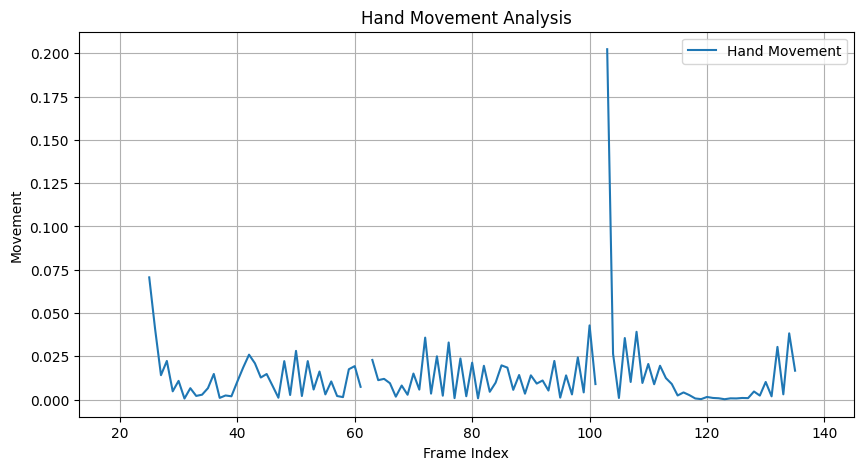

In [49]:
import cv2
import mediapipe as mp
import numpy as np
import matplotlib.pyplot as plt

# Function to save frames to a directory
def save_frame(directory, frame, frame_index, label=""):
    os.makedirs(directory, exist_ok=True)  # Create directory if it doesn't exist
    filename = f"{directory}/frame_{frame_index:04d}_{label}.jpg"
    cv2.imwrite(filename, frame)

# Initialize MediaPipe Hands
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(static_image_mode=False, max_num_hands=1, min_detection_confidence=0.7)

# Video capture
cap = cv2.VideoCapture(asl_sentence_vid)

# Check if the video is opened successfully
if not cap.isOpened():
    print("Error: Could not open video.")
    exit()

# Initialize variables
frame_count = 0
prev_landmark = None
movement_list = []

# Create directories for storing frames
original_frames_dir = output_dir + "/frames/original"

# Process video frames
while cap.isOpened():
    success, frame = cap.read()
    if not success:
        break

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = hands.process(frame_rgb)

    # Check if any hand landmarks are detected
    if results.multi_hand_landmarks:
        save_frame(original_frames_dir, frame, frame_count, label="hand")
        print(f"{frame_count}: Hand detected at frame ")
        for hand_landmarks in results.multi_hand_landmarks:
            # Get the coordinates of the wrist (landmark 0)
            current_landmark = np.array([hand_landmarks.landmark[0].x, hand_landmarks.landmark[0].y])

            # Calculate movement (Euclidean distance) between current frame and previous frame
            if prev_landmark is not None:
                movement = np.linalg.norm(current_landmark - prev_landmark)
                movement_list.append(movement)

            prev_landmark = current_landmark
    else:
        # If no hand is detected, append NaN to indicate break in the line
        save_frame(original_frames_dir, frame, frame_count, label="no hand")
        print(f"{frame_count}: No Hand detected at frame ")
        movement_list.append(np.nan)

    frame_count += 1

# Release the video capture and close MediaPipe hands
cap.release()
hands.close()

# Plot the movement over frames
plt.figure(figsize=(10, 5))
plt.plot(movement_list, label='Hand Movement')
plt.xlabel('Frame Index')
plt.ylabel('Movement')
plt.title('Hand Movement Analysis')
plt.legend()
plt.grid(True)
plt.show()

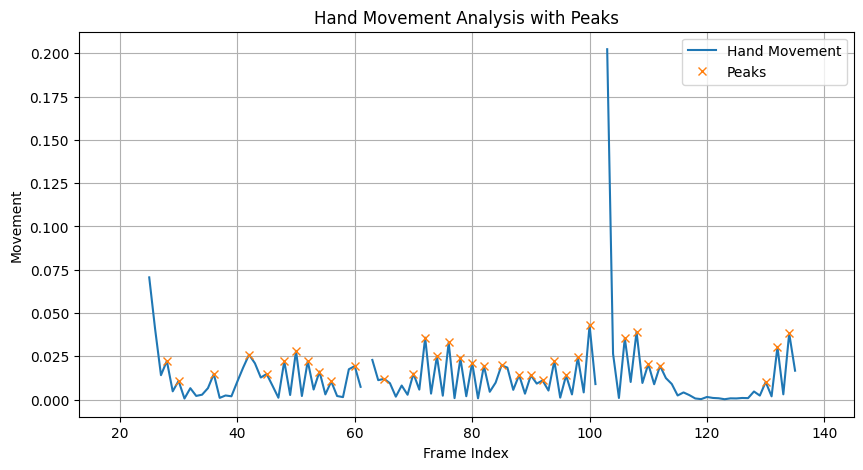

In [45]:
from scipy.signal import find_peaks

# Find peaks in the movement data
peaks, _ = find_peaks(movement_list, height=0.01)  # Adjust 'height' parameter as needed

# Plot movement with peaks marked
plt.figure(figsize=(10, 5))
plt.plot(movement_list, label='Hand Movement')
plt.plot(peaks, np.array(movement_list)[peaks], "x", label='Peaks')
plt.xlabel('Frame Index')
plt.ylabel('Movement')
plt.title('Hand Movement Analysis with Peaks')
plt.legend()
plt.grid(True)
plt.show()


# **Plotting of hand postioning**

0: No hand detected at frame 
1: No hand detected at frame 
2: No hand detected at frame 
3: No hand detected at frame 
4: No hand detected at frame 
5: No hand detected at frame 
6: No hand detected at frame 
7: No hand detected at frame 
8: No hand detected at frame 
9: No hand detected at frame 
10: No hand detected at frame 
11: No hand detected at frame 
12: No hand detected at frame 
13: No hand detected at frame 
14: No hand detected at frame 
15: No hand detected at frame 
16: No hand detected at frame 
17: No hand detected at frame 
18: No hand detected at frame 


/usr/local/lib/python3.10/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


19: Hand detected at frame 
20: Hand detected at frame 
21: No hand detected at frame 
22: Hand detected at frame 
23: No hand detected at frame 
24: Hand detected at frame 
25: No hand detected at frame 
26: Hand detected at frame 
27: Hand detected at frame 
28: Hand detected at frame 
29: Hand detected at frame 
30: Hand detected at frame 
31: Hand detected at frame 
32: Hand detected at frame 
33: Hand detected at frame 
34: Hand detected at frame 
35: Hand detected at frame 
36: Hand detected at frame 
37: Hand detected at frame 
38: Hand detected at frame 
39: Hand detected at frame 
40: Hand detected at frame 
41: Hand detected at frame 
42: Hand detected at frame 
43: Hand detected at frame 
44: Hand detected at frame 
45: Hand detected at frame 
46: Hand detected at frame 
47: Hand detected at frame 
48: Hand detected at frame 
49: Hand detected at frame 
50: Hand detected at frame 
51: Hand detected at frame 
52: Hand detected at frame 
53: Hand detected at frame 
54: Hand de

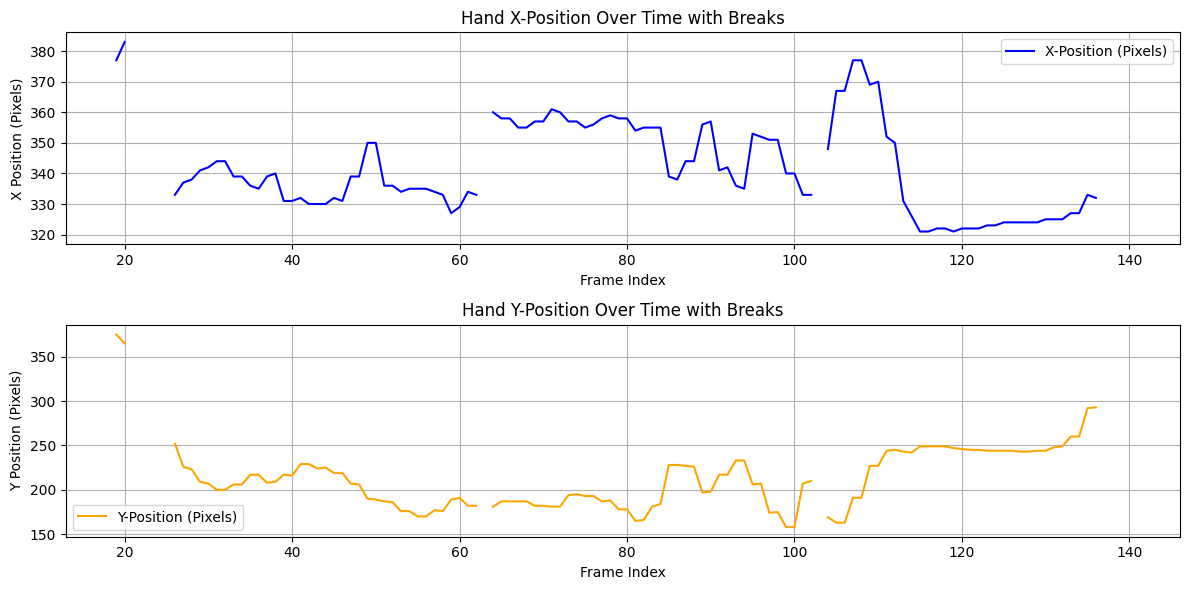

In [47]:
import cv2
import mediapipe as mp
import numpy as np
import matplotlib.pyplot as plt
import os

# Function to save frames to a directory
def save_frame(directory, frame, frame_index, label=""):
    os.makedirs(directory, exist_ok=True)  # Create directory if it doesn't exist
    filename = f"{directory}/frame_{frame_index:04d}_{label}.jpg"
    cv2.imwrite(filename, frame)

# Initialize MediaPipe Hands
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(static_image_mode=False, max_num_hands=1, min_detection_confidence=0.7)

# Video capture
cap = cv2.VideoCapture(asl_sentence_vid)

# Get video frame dimensions and total frame count
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Initialize variables
frame_count = 0
x_positions = []
y_positions = []

# Define weights for the fingertips
weights = {
    4: 1.5,   # Thumb Tip
    8: 2.0,   # Index Finger Tip
    12: 2.0,  # Middle Finger Tip
    16: 1.0,  # Ring Finger Tip
    20: 0.5   # Pinky Finger Tip
}

# Create directories for storing frames
original_frames_dir = output_dir + "/frames/original"

# Process video frames
while cap.isOpened():
    success, frame = cap.read()
    if not success:
        break

    # Save the original frame for debugging purposes
    #save_frame(original_frames_dir, frame, frame_count, label="original")

    # Convert frame to RGB
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = hands.process(frame_rgb)

    if results.multi_hand_landmarks:
        # If hand landmarks are detected
        save_frame(original_frames_dir, frame, frame_count, label="hand")
        print(f"{frame_count}: Hand detected at frame ")
        for hand_landmarks in results.multi_hand_landmarks:
            # Initialize variables for weighted sum
            weighted_sum_x = 0
            weighted_sum_y = 0
            total_weight = 0

            # Calculate weighted average of the selected fingertips
            for idx, weight in weights.items():
                # Get the normalized coordinates of the fingertip
                norm_x = hand_landmarks.landmark[idx].x
                norm_y = hand_landmarks.landmark[idx].y

                # Calculate weighted sum
                weighted_sum_x += norm_x * weight
                weighted_sum_y += norm_y * weight
                total_weight += weight

            # Compute the weighted average for x and y coordinates
            weighted_avg_x = weighted_sum_x / total_weight
            weighted_avg_y = weighted_sum_y / total_weight

            # Convert normalized coordinates to pixel coordinates
            x_pixel = int(weighted_avg_x * frame_width)
            y_pixel = int(weighted_avg_y * frame_height)

            # Store the pixel positions in lists
            x_positions.append(x_pixel)
            y_positions.append(y_pixel)
    else:
        # If no hand is detected, append NaN to indicate break in the line
        save_frame(original_frames_dir, frame, frame_count, label="NO hand")
        print(f"{frame_count}: No hand detected at frame ")
        x_positions.append(np.nan)
        y_positions.append(np.nan)

    frame_count += 1

# Release the video capture and close MediaPipe hands
cap.release()
hands.close()

# Plot X and Y positions over time with breaks when no hand is detected
plt.figure(figsize=(12, 6))

# X-coordinate plot with breaks
plt.subplot(2, 1, 1)
plt.plot(x_positions, label='X-Position (Pixels)', color='blue')
plt.xlabel('Frame Index')
plt.ylabel('X Position (Pixels)')
plt.title('Hand X-Position Over Time with Breaks')
plt.legend()
plt.grid(True)

# Y-coordinate plot with breaks
plt.subplot(2, 1, 2)
plt.plot(y_positions, label='Y-Position (Pixels)', color='orange')
plt.xlabel('Frame Index')
plt.ylabel('Y Position (Pixels)')
plt.title('Hand Y-Position Over Time with Breaks')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# **Mixed method**


1.   Step 1: Detect frames where a hand is visible using MediaPipe and track the movement between frames.
2.   Step 2: Extract the frames where the hand is visible and store them in a list for further processing.
3.   Step 3: Use the extracted frames and apply change point detection to identify n groups of frames based on similarity.
4.   Step 4: Save representative frames from each detected group to visually validate the segmentation.

/usr/local/lib/python3.10/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


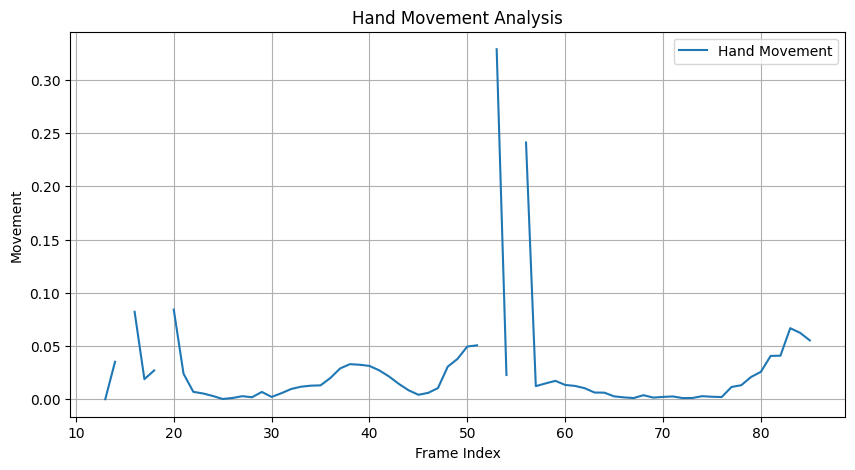

Intervals: [(14, 29), (29, 44), (44, 85)]
Saved segment information to /content/drive/MyDrive/ASL_Video_Clips/ASL TEACHER YOU/segment_info.json
Segment Information JSON:
[
    {
        "segment_id": 1,
        "start_frame": 14,
        "end_frame": 29
    },
    {
        "segment_id": 2,
        "start_frame": 29,
        "end_frame": 44
    },
    {
        "segment_id": 3,
        "start_frame": 44,
        "end_frame": 85
    }
]
Total frames analyzed: 93
Change points (segmentation): [22, 37, 69]
Saved segment information to JSON file: /content/drive/MyDrive/ASL_Video_Clips/ASL TEACHER YOU/segment_info.json


In [10]:
import cv2
import mediapipe as mp
import numpy as np
import matplotlib.pyplot as plt
import os
import ruptures as rpt
import json

# Parameters # Create directories for storing frames
json_path = f"{output_dir}/segment_info.json"  # Path for the JSON output file
all_frames_dir = f"{output_dir}/frames" # Path for the frames
os.makedirs(all_frames_dir, exist_ok=True)
n = 3  # Number of words in the sentence, adjust based on your case

# Initialize MediaPipe Hands
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(static_image_mode=False, max_num_hands=1, min_detection_confidence=0.7)

# Function to save frames to a directory
def save_frame(directory, frame, frame_index, label=""):
    os.makedirs(directory, exist_ok=True)  # Create directory if it doesn't exist
    filename = f"{directory}/frame_{frame_index:04d}_{label}.jpg"
    cv2.imwrite(filename, frame)

# Function to extract features from a frame (resize and flatten)
def extract_frame_features(frame, size=(64, 64)):
    resized_frame = cv2.resize(frame, size)  # Resize the frame for feature extraction
    return resized_frame.flatten()  # Flatten the frame into a 1D array


# Video capture
cap = cv2.VideoCapture(asl_sentence_vid)

# Check if the video is opened successfully
if not cap.isOpened():
    print("Error: Could not open video.")
    exit()

# Initialize variables
frame_count = 0
movement_list = []
hand_frames = []  # To store frames with visible hand movements
raw_hand_frames = []  # To store raw frames for each hand-detected frame
frame_indices = []  # To store frame indices where hand is visible


# Step 1: Detect frames with hand movements using MediaPipe
prev_landmark = None

while cap.isOpened():
    success, frame = cap.read()
    if not success:
        break

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = hands.process(frame_rgb)

    # Check if any hand landmarks are detected
    if results.multi_hand_landmarks:
        save_frame(all_frames_dir, frame, frame_count, label="hand")

        for hand_landmarks in results.multi_hand_landmarks:
            # Get the coordinates of the wrist (landmark 0)
            current_landmark = np.array([hand_landmarks.landmark[0].x, hand_landmarks.landmark[0].y])

            # Calculate movement (Euclidean distance) between current frame and previous frame
            if prev_landmark is not None:
                movement = np.linalg.norm(current_landmark - prev_landmark)
                movement_list.append(movement)
            else:
                movement_list.append(0)  # No movement for the first frame with hand

            prev_landmark = current_landmark

            # Store the frame and frame index for further processing
            hand_frames.append(extract_frame_features(frame))  # Extract and store frame features
            raw_hand_frames.append(frame)  # Store the raw frame
            frame_indices.append(frame_count)
    else:
        # If no hand is detected, append NaN to indicate break in the movement list
        save_frame(all_frames_dir, frame, frame_count, label="no_hand")
        movement_list.append(np.nan)

    frame_count += 1

# Release the video capture and close MediaPipe hands
cap.release()
hands.close()

# Plot the movement over frames for visual analysis
plt.figure(figsize=(10, 5))
plt.plot(movement_list, label='Hand Movement')
plt.xlabel('Frame Index')
plt.ylabel('Movement')
plt.title('Hand Movement Analysis')
plt.legend()
plt.grid(True)
plt.show()

# Step 2: Apply change point detection on frames with visible hand movements
hand_frames_np = np.array(hand_frames)  # Convert list to numpy array

# Use Kernel-based change point detection
model = rpt.KernelCPD(kernel="linear").fit(hand_frames_np)
change_points = model.predict(n_bkps=n-1)  # n-1 change points, where n is the number of words

# Step 3: Create segments using custom logic
def find_intervals(mid_points, global_start, global_finish):
    n = len(mid_points)
    mid_points = sorted(mid_points)  # Sort the midpoints to ensure correct ordering

    # Calculate half the distances between consecutive midpoints
    distances = np.diff(mid_points) / 2

    # Calculate the start of each interval
    starts = [mid_points[0] - distances[0]]  # Start of first interval based on first midpoint
    for i in range(1, n):
        starts.append(mid_points[i] - distances[i-1])

    # Calculate the end of each interval
    ends = [mid_points[i] + distances[i-1] for i in range(1, n)]
    ends.insert(0, mid_points[0] + distances[0])  # End of the first interval
    ends.append(mid_points[-1] + distances[-1])  # End of last interval based on last midpoint

    # Adjust ends and starts to avoid overlap and ensure proper interval formation
    for i in range(1, len(starts)):
        starts[i] = ends[i - 1]  # Start of current interval should be the end of the previous one

    # Check if the intervals exceed global_start or global_finish bounds
    if starts[0] < global_start:
        starts[0] = global_start
    if ends[-1] > global_finish:
        ends[-1] = global_finish

    # Zip starts and ends to form intervals and ensure all values are integers
    intervals = list(zip(map(int, starts), map(int, ends)))

    return intervals

def write_json(intervals):
    # Create the JSON structure
    segment_info = []

    # Iterate over intervals and create segment information
    for i, (start_frame, end_frame) in enumerate(intervals):
        segment = {
            "segment_id": i + 1,
            "start_frame": start_frame,
            "end_frame": end_frame
        }
        segment_info.append(segment)

    # Save the segment information to a JSON file in the "temp" directory
    with open(json_path, 'w') as json_file:
        json.dump(segment_info, json_file, indent=4)

    print(f"Saved segment information to {json_path}")

    # Print the content of the JSON file to verify
    print("Segment Information JSON:")
    print(json.dumps(segment_info, indent=4))


intervals = find_intervals(change_points, global_start = 0, global_finish = frame_count)
print("Intervals:", intervals)
write_json(intervals)

# Step 4: Display summary and output
print(f"Total frames analyzed: {frame_count}")
print(f"Change points (segmentation): {change_points}")
print(f"Saved segment information to JSON file: {json_path}")

